In [2]:
import sys
sys.path.append(r'../ThinkDSP/code')

import ThinkDSP.code.thinkdsp as thinkdsp

In [7]:
import numpy as np
import matplotlib.pyplot as plt

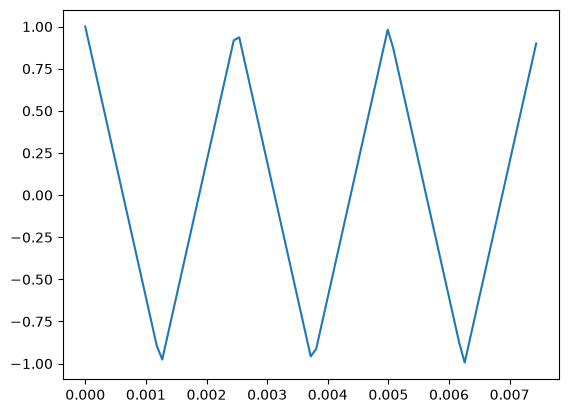

In [6]:
#wrong
sawtooth = thinkdsp.TriangleSignal(400)
sawtooth.plot()
wave = sawtooth.make_wave(duration = 1, framerate = 40000)
wave.make_audio()

In [8]:
# sawtooth is subclass of sinusoid
class SawtoothSignal(thinkdsp.Sinusoid):
    def evaluate(self, ts):
        """Evaluates the signal at the given times.

        ts: float array of times

        returns: float wave array
        """
        cycles = self.freq * ts + self.offset / np.pi / 2
        frac, _ = np.modf(cycles)
        ys = thinkdsp.normalize(thinkdsp.unbias(frac), self.amp)
        return ys

In [9]:
sawtooth = SawtoothSignal().make_wave(duration=0.5, framerate=40000)
sawtooth.make_audio()

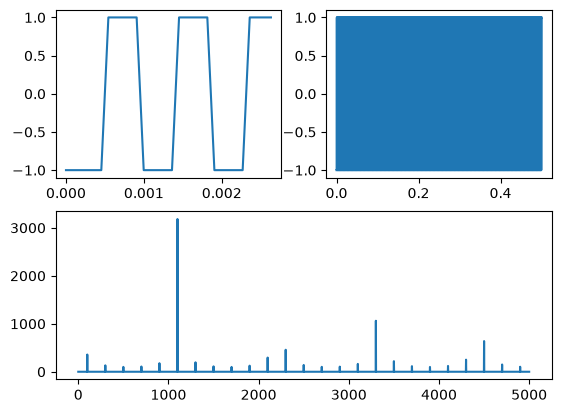

In [16]:
squareSignal = thinkdsp.SquareSignal(1100)
plt.subplot(2, 2, 1)
squareSignal.plot()
waveSquareSignal = squareSignal.make_wave(duration = 0.5, framerate = 10000)
plt.subplot(2, 2, 2)
waveSquareSignal.plot()

spectrum = waveSquareSignal.make_spectrum()
plt.subplot(2, 1, 2)
spectrum.plot()
waveSquareSignal.make_audio()

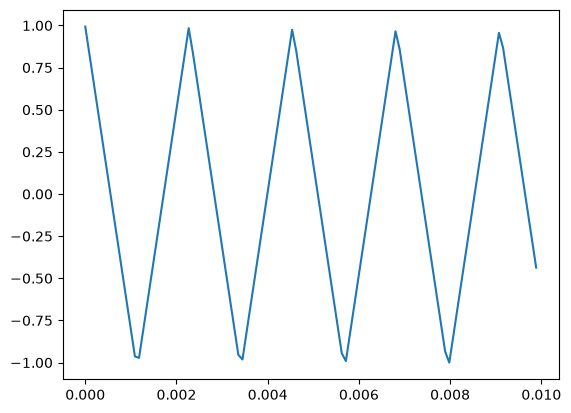

In [27]:
# triangle signal 440hz and duration = 0.01 for wave
tSignal = thinkdsp.TriangleSignal()
wave = tSignal.make_wave(duration = 0.01)
wave.plot()

(1.0436096431476471e-14+0j)
56


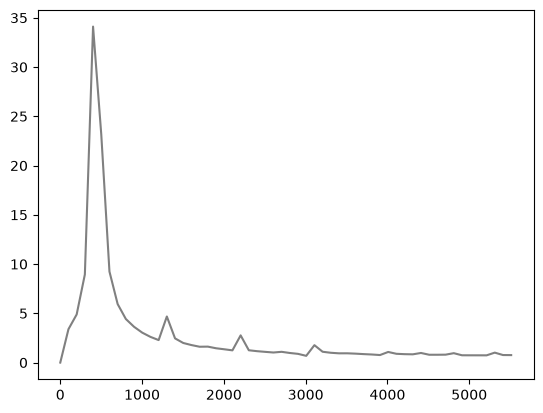

In [28]:
spectrum = wave.make_spectrum()
print(spectrum.hs[0])
print(len(spectrum))
spectrum.plot(color = 'gray')


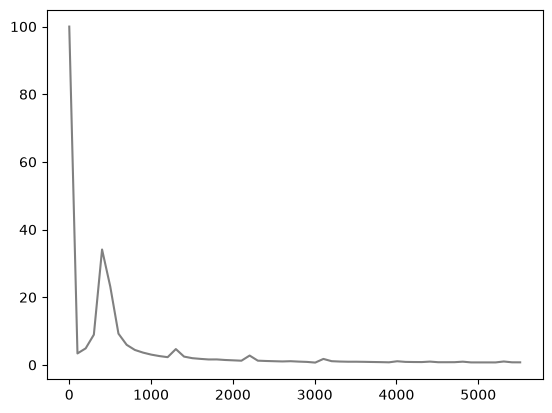

In [29]:
spectrum.hs[0] = 100
spectrum.plot(color = 'gray')

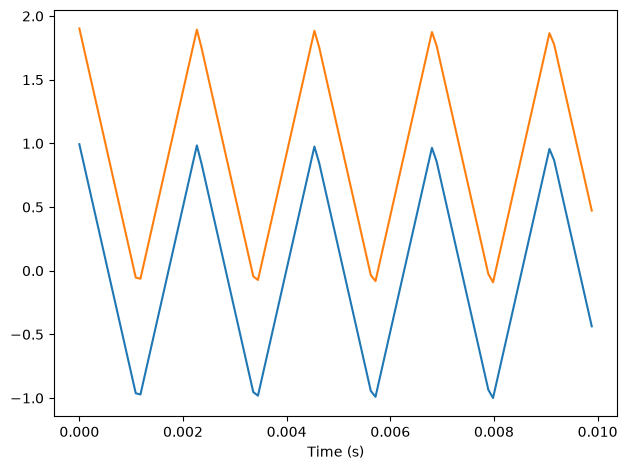

In [31]:
wave.plot()
spectrum.make_wave().plot()
thinkdsp.decorate(xlabel='Time (s)')